In [1]:
%pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

c:\Users\supre\Desktop\ecommerce-analytics-forcasting\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [3]:
# Load cleaned data
df = pd.read_csv("../data/cleaned_data.csv")

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
1,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30
2,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50
3,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
4,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10


In [5]:
# Create a Revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [6]:
# Ensure InvoiceDate is datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
daily_sales = df.groupby(df["InvoiceDate"].dt.date)["Revenue"].sum().reset_index()
daily_sales.columns = ["ds", "y"]   # Prophet expects ds = date, y = value

In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Revenue'],
      dtype='object')

In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Revenue
0,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
1,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30,15.30
2,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50,25.50
3,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,11.10
4,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,11.10


In [9]:
# Build Prophet model
model = Prophet()
model.fit(daily_sales)

# Make future dataframe (next 90 days)
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)


21:13:34 - cmdstanpy - INFO - Chain [1] start processing
21:13:35 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
#predicted forcasted values from model
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
390,2012-03-04,50782.007551,33692.689248,67661.079675
391,2012-03-05,62066.364302,44131.975065,78727.383965
392,2012-03-06,66577.911371,48754.160075,84165.548141
393,2012-03-07,64037.569178,46781.709530,80219.387951
394,2012-03-08,70895.294194,52239.525137,86934.705581


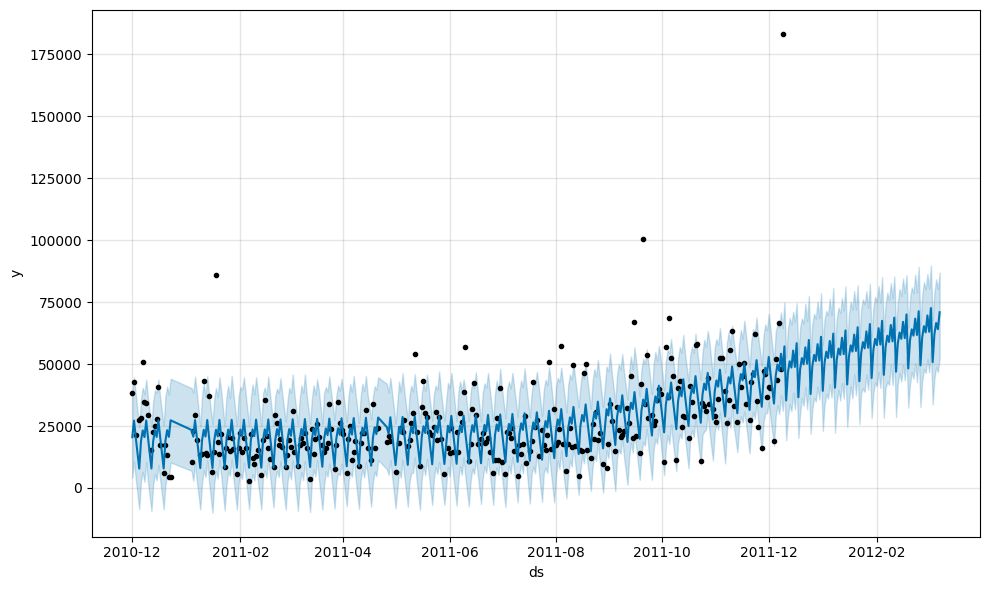

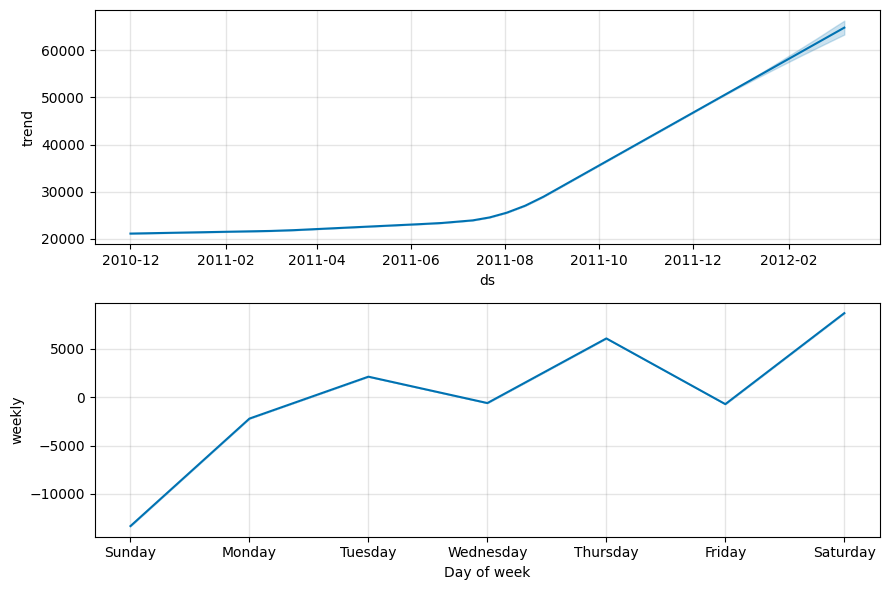

In [11]:
# Plot
fig1 = model.plot(forecast)
plt.show()

# Trend & seasonality
fig2 = model.plot_components(forecast)
plt.show()

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

from datetime import datetime

# Train-test split
split_date = datetime.strptime("2011-09-01", "%Y-%m-%d").date()
train = daily_sales[daily_sales['ds'] < split_date]
test  = daily_sales[daily_sales['ds'] >= split_date]

model = Prophet()
model.fit(train)

future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

# Evaluate
y_true = test['y'].values
y_pred = forecast.tail(len(test))['yhat'].values
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE:", mae, " RMSE:", rmse)

21:13:59 - cmdstanpy - INFO - Chain [1] start processing
21:13:59 - cmdstanpy - INFO - Chain [1] done processing


MAE: 17619.73381915509  RMSE: 26898.533915822583


In [14]:
#save the model
import joblib
joblib.dump(model, '../model/prophet_model.pkl')

['../model/prophet_model.pkl']